Con riferimento al data set dell’esercitazione su clustering, eseguire una classificazione binaria sulla feature death, una classificazione multiclasse sulla feature dzgroup ed una regressione sulla feature aps.

**Classificazione binaria su "death"**

1. Procedere allo split train-test secondo il rapporto 95%-5% in forma stratificata secondo i valori della variabile target.

In [11]:
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv(".\dataset_esercitazione.csv", sep=',')
print(df)

X = df.drop(columns=['death'])
y = df['death']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)

print(f"Dimensioni del dataset originale: {X.shape[0]} pazienti")
print(f"Dimensioni del Training Set (95%): {X_train.shape[0]} pazienti")
print(f"Dimensioni del Test Set (5%): {X_test.shape[0]} pazienti")

#la PCA, come trasformazione, si applica soltanto quando sono certo che non vi sia il bisogno di "spiegare" il modello,
#dunque quando non ho bisogno di elencare quali feature hanno condizionato la risposta

           age     sex            dzgroup             dzclass  num.co   edu  \
0     62.84998    male        Lung Cancer              Cancer       0  11.0   
1     60.33899  female          Cirrhosis  COPD/CHF/Cirrhosis       2  12.0   
2     52.74698  female          Cirrhosis  COPD/CHF/Cirrhosis       2  12.0   
3     42.38498  female        Lung Cancer              Cancer       2  11.0   
4     79.88495  female  ARF/MOSF w/Sepsis            ARF/MOSF       1   NaN   
...        ...     ...                ...                 ...     ...   ...   
9100  66.07300    male  ARF/MOSF w/Sepsis            ARF/MOSF       1   8.0   
9101  55.15399  female               Coma                Coma       1  11.0   
9102  70.38196    male  ARF/MOSF w/Sepsis            ARF/MOSF       1   NaN   
9103  47.01999    male       MOSF w/Malig            ARF/MOSF       1  13.0   
9104  81.53894  female  ARF/MOSF w/Sepsis            ARF/MOSF       1   8.0   

          income  scoma  charges      totcst  ...  

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\giova\AppData\Local\Temp\ipykernel_20316\3797843509.py:4: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv(".\dataset_esercitazione.csv", sep=',')


2. Eseguire l’imputazione dei dati mancanti con le stesse strategie dell’esercitazione precedente.

In [12]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

cat_values = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()
num_values = X_train.select_dtypes(include=['number']).columns.tolist()

#per gestire i dati mancanti
report_missing = X_train.isnull().sum() / len(X_train) * 100
print(f"Percentuale dati mancanti:\n{report_missing}")

#contiamo le colonne con i dati mancanti
nan_columns = report_missing[report_missing > 0].index.tolist()
missing_cat = [col for col in nan_columns if col in cat_values]
missing_num = [col for col in nan_columns if col in num_values]

#imputazione per variabili numeriche e categoriche
if len(missing_num) > 0:
    imputer_num = SimpleImputer(strategy='median')
    X_train[missing_num] = imputer_num.fit_transform(X_train[missing_num])
    X_test[missing_num] = imputer_num.transform(X_test[missing_num])
if len(missing_cat) > 0:
    imputer_cat = SimpleImputer(strategy='constant', fill_value='Unknown')
    X_train[missing_cat] = imputer_cat.fit_transform(X_train[missing_cat])
    X_test[missing_cat] = imputer_cat.transform(X_test[missing_cat])

#encoding per variabili categoriche
if len(cat_values) > 0:
    encoder_cat = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-5)
    X_train[cat_values] = encoder_cat.fit_transform(X_train[cat_values])
    X_test[cat_values] = encoder_cat.transform(X_test[cat_values])

Percentuale dati mancanti:
age          0.000000
sex          0.000000
dzgroup      0.000000
dzclass      0.000000
num.co       0.000000
edu         17.724592
income      32.708984
scoma        0.011562
charges      1.942421
totcst       9.862412
totmcst     38.200948
avtisst      0.901838
race         0.404671
sps          0.011562
aps          0.011562
surv2m       0.011562
surv6m       0.011562
hday         0.000000
diabetes     0.000000
dementia     0.000000
ca           0.000000
prg2m       18.210198
prg6m       18.036767
dnr          0.346861
dnrday       0.346861
meanbp       0.000000
wblc         2.312406
hrt          0.000000
resp         0.000000
temp         0.000000
pafi        25.609897
alb         36.836629
bili        28.511967
crea         0.751532
sod          0.000000
ph          25.147416
glucose     49.381431
bun         47.739623
urine       53.405018
adlp        61.810614
adls        31.402474
adlsc        0.000000
dtype: float64


3. Rimuovere le feature che presentano elevata correlazione con la variabile target e successivamente analizzare le possibili feature multicollineari rimanenti.

In [ ]:
import numpy as np
import matplotlib.pyplot as plot

df_train = X_train.copy()
df_train['death'] = y_train  #uniamo X_train e y_train

#calcoliamo la correlazione assoluta con 'death'
death_corr = df_train.corr()['death'].drop('death').abs().sort_values(ascending=False)
print(f"Correlazione feature con 'death':\n{death_corr}")

#matrice di correlazione
corr_matrix = X_train.corr().abs()
#print(corr_matrix)

#analisi e gestione della multicollinearità
rel_threshold = 0.7
corr_pairs = corr_matrix.unstack().sort_values(key=abs)
corr_pairs = corr_pairs[corr_pairs != 1.0]  #eliminiamo l'autocorrelazione
related_pairs = corr_pairs[abs(corr_pairs) > rel_threshold]
print(related_pairs.sort_values(ascending=False))

var_to_remove = ['charges', 'aps', 'adlsc', 'prg2m', 'surv2m']  #zona grigia su quali variabili droppare (meno correlate con death ma altamente correlate tra loro)
X_train = X_train.drop(columns=var_to_remove)
X_test = X_test.drop(columns=var_to_remove)


Correlazione feature con 'death':
surv6m      0.376137
dnr         0.372086
prg6m       0.345298
surv2m      0.323088
prg2m       0.273103
dzgroup     0.264856
age         0.177115
adlsc       0.157424
sps         0.155591
aps         0.155095
dzclass     0.153538
dnrday      0.150054
scoma       0.134407
ca          0.119953
avtisst     0.115725
adls        0.093466
num.co      0.070085
hday        0.064187
dementia    0.047128
sex         0.029603
meanbp      0.029532
temp        0.029261
totmcst     0.028043
race        0.024511
crea        0.024276
bili        0.022891
glucose     0.021574
totcst      0.018973
bun         0.018958
urine       0.018509
income      0.018247
sod         0.017839
charges     0.017454
diabetes    0.012219
alb         0.011410
ph          0.008047
adlp        0.007184
wblc        0.006214
pafi        0.004135
edu         0.002976
hrt         0.002647
resp        0.002084
Name: death, dtype: float64
Rilevate coppie con correlazione superiore a 0.7
Correla

4. Utilizzare RandomForestClassifier per la classificazione e RandomForestRegressor per la regressione con i seguenti iperparametri(*)
    a. Classificatore
        i. criterion: “gini”, “log_loss”
        ii. min_samples_split: 2, 5, 10
        iii. max_features: “sqrt”, 5
    b. Regressore
        i. criterion: “squared_error”, “absolute_error”
        ii. min_samples_split: 2, 5, 10
        iii. max_features: “sqrt”, 5

In [ ]:
#per la classificazione binaria su 'death' utilizziamo il RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

iperparam_grid = {
    'criterion': ["gini", "log_loss"],
    'min_samples_split': [2, 5, 10],
    'max_features': ["sqrt", 5]
}

clf = RandomForestClassifier(random_state=42)  #modello base
grid_search_clf = GridSearchCV(
    estimator=clf,
    param_grid=iperparam_grid,
    cv=5,  #cross-validation a 5 fold
    scoring='accuracy',
    n_jobs=-1
)

grid_search_clf.fit(X_train, y_train)  #addestriamo il modello
print(f"Risultati Grid Search - Migliori iperparametri trovati: {grid_search_clf.best_params_}\nMiglior accuratezza: {grid_search_clf.best_score_:.4f}")

Risultati Grid Search - Migliori iperparametri trovati: {'criterion': 'log_loss', 'max_features': 'sqrt', 'min_samples_split': 10}
Miglior accuratezza: 0.7785


5. Valutare il regressore sul test set con la metrica R2, il classificatore binario con la curva ROC e la relativa AUC ed il classificatore multiclasse con le curve ROC e le AUC di ogni classe, ciascuna valutata in modalità one-vs-rest.

PERFORMANCE SUL TEST SET - Accuracy: 0.8136, ROC-AUC Score: 0.8608

Report di Classificazione dettagliato:
              precision    recall  f1-score   support

           0       0.73      0.65      0.69       145
           1       0.84      0.89      0.87       311

    accuracy                           0.81       456
   macro avg       0.79      0.77      0.78       456
weighted avg       0.81      0.81      0.81       456



<Figure size 800x600 with 0 Axes>

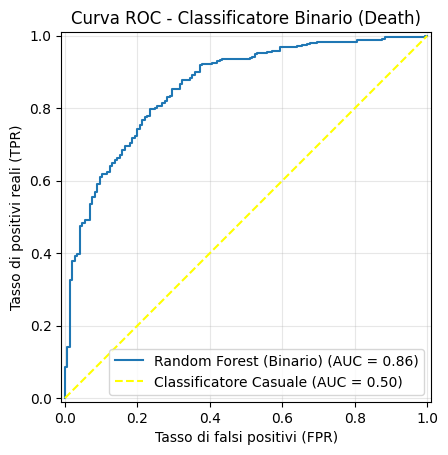

In [58]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, RocCurveDisplay

best_clf = grid_search_clf.best_estimator_  #estrazione del modello vincente dalla Grid Search

#previsione e probabilità
y_pred = best_clf.predict(X_test)
y_pred_proba = best_clf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"PERFORMANCE SUL TEST SET - Accuracy: {accuracy:.4f}, ROC-AUC Score: {roc_auc:.4f}")
print("\nReport di Classificazione dettagliato:")
print(classification_report(y_test, y_pred))

#curva ROC
plot.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(best_clf, X_test, y_test, name="Random Forest (Binario)")
#from_estimator calcola e disegna la curva in automatico passandogli il modello e il test set

#aggiungiamo la diagonale rossa che rappresenta un classificatore casuale
plot.plot([0, 1], [0, 1], color='yellow', linestyle='--', label='Classificatore Casuale (AUC = 0.50)')

plot.title('Curva ROC - Classificatore Binario (Death)')
plot.xlabel('Tasso di falsi positivi (FPR)')
plot.ylabel('Tasso di positivi reali (TPR)')
plot.legend(loc='lower right')
plot.grid(alpha=0.3)
plot.show()